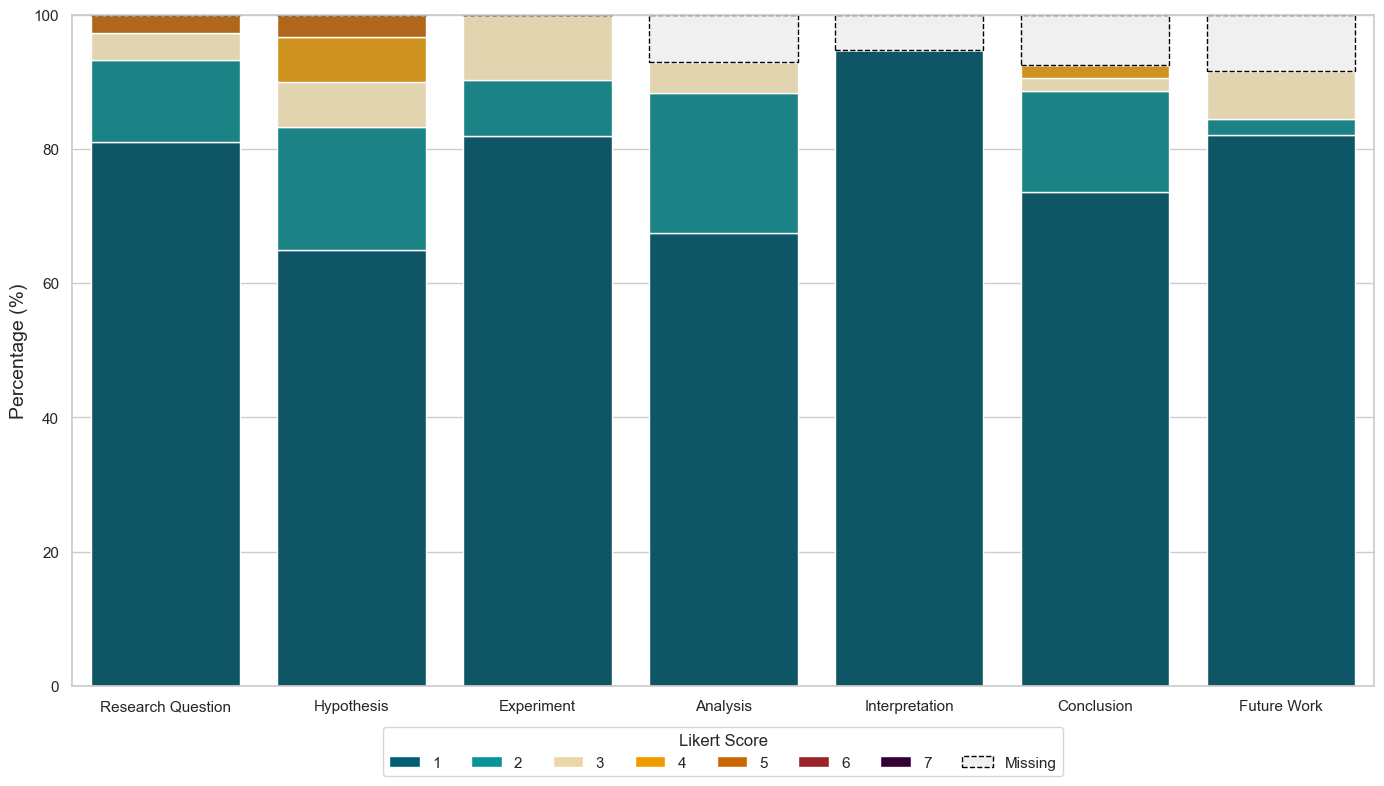

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Load the dataframe from your csv file
file_path = 'output.csv'
df = pd.read_csv(file_path)

# --- Data Transformation for 100% Stacked Bar Chart ---

# 1. Map original field names to new, shorter names
# 1. Map original field names to new, shorter names, grouping suggestions
#    into 'Future Work'.
field_mapping = {
    'Research Question Likert Score': 'Research Question',
    'Hypothesis Likert Score': 'Hypothesis',
    'Experiment Description Likert Score': 'Experiment',
    'Analysis Likert Score': 'Analysis',
    'Interpretation Likert Score': 'Interpretation',
    'Conclusion Likert Score': 'Conclusion',
    'Suggested Research Question Likert Score': 'Future Work',
    'Suggested Hypothesis Likert Score': 'Future Work'
}
df['section'] = df['section'].map(field_mapping)

# 2. Define the desired order for the fields
field_order = [
    'Research Question',
    'Hypothesis',
    'Experiment',
    'Analysis',
    'Interpretation',
    'Conclusion',
    'Future Work'
]

# Create a cross-tabulation to count occurrences of each Likert 'value' for each 'section'
counts_df = pd.crosstab(df['section'], df['value'])

# 3. Reorder the DataFrame according to the specified field_order
#    and ensure all Likert values (-1 and 1-7) are present as columns.
all_scores = [1, 2, 3, 4, 5, 6, 7, -1]
counts_df = counts_df.reindex(field_order, fill_value=0).reindex(columns=all_scores, fill_value=0)

# Calculate the percentage of each Likert score for each field
percentages_df = counts_df.div(counts_df.sum(axis=1), axis=0) * 100

# --- Plotting ---

# Set up the plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

# Create the 100% stacked bar chart
# The `bottom` parameter is updated in each iteration to stack the bars
bottom = pd.Series([0.0] * len(percentages_df), index=percentages_df.index)

# 4. Define colors for the Likert scale values
colors = {
    -1: "#f0f0f0",
    1: "#005f73",
    2: "#0a9396",
    3: "#e9d8a6",
    4: "#ee9b00",
    5: "#ca6702",
    6: "#9b2226",
    7: "#330033"
}

# --- Build color map (green → red) ---
# import numpy as np
# scores = [1,2,3,4,5,6,7]
# norm_vals = (np.array(scores) - min(scores)) / (max(scores) - min(scores))
# colors = plt.cm.RdYlGn_r(norm_vals)


for score in percentages_df.columns:
    bar_kwargs = {
        'color': colors[score],
        'label': str(score)
    }
    if score == -1:
        bar_kwargs['edgecolor'] = 'black'
        bar_kwargs['linestyle'] = '--'
        bar_kwargs['linewidth'] = 1

    ax = sns.barplot(
        x=percentages_df.index,
        y=percentages_df[score],
        order=percentages_df.index,
        bottom=bottom,
        **bar_kwargs
    )
    # Update the bottom for the next stack
    bottom += percentages_df[score]

# --- Formatting and Labels ---

# Add titles and labels for clarity
ax.set_xlabel(None)
ax.set_ylabel('Percentage (%)', fontsize=14)

# Define full set of possible labels
all_legend_labels = {
    1: "1 - Nearly Perfect",
    2: "2 - Correct",
    3: "3 - Acceptable",
    4: "4 - Partially Incorrect",
    5: "5 - Incorrect",
    6: "6 - No overlap",
    7: "7 - Hallucinatory",
    -1: "Missing"
}

# Create legend handles and labels for all possible scores (1-7)
legend_handles = []
legend_labels = []
for score in all_scores:
    patch_kwargs = {'facecolor': colors[score]}
    if score == -1:
        patch_kwargs['edgecolor'] = 'black'
        patch_kwargs['linestyle'] = '--'
        patch_kwargs['linewidth'] = 1
    legend_handles.append(Patch(**patch_kwargs))
    legend_labels.append(str(score) if score != -1 else "Missing")

# Add a legend with custom handles to ensure colors are displayed correctly
xtick_labels = [label.replace(' ', '\n') if ' ' in label else label for label in percentages_df.index]
ax.legend(handles=legend_handles, labels=legend_labels, title='Likert Score', loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=len(all_scores))

# Ensure the layout is tight
plt.tight_layout()

# Display the plot
plt.savefig(f"plots/likert_scale_bars.pdf", dpi=600)
plt.show()
